In [ ]:
!pip install -q clickhouse-connect pandas seaborn

In [ ]:
from config import client
import pandas as pd

In [ ]:
batch_number_in_query = "SELECT * FROM zoho_books_analytics.batch_number_in"

result = client.query(batch_number_in_query)

batch_number_in_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

# print(batch_number_in_df.head())

### Column and Their Descriptions

batch_in_id → Unique identifier for the batch-in transaction.

product_id → Identifier of the associated product.

batch_number → The assigned batch number.

batch_reference → Reference information for the batch.

batch_manufactured_date → Manufacturing date of the batch.

batch_expiry_date → Expiration date of the batch.

quantity_in → Quantity received in the batch.

balance_quantity → 

warehouse_id → Identifier of the warehouse storing the batch.

entity_type → Type of entity linked to the batch.

account_balance_id → Identifier for account balance reference.

account_split_id → Identifier for account split reference.

bill_id → Identifier of the related bill.

bill_item_id → Identifier of the related bill item.

creditnotes_id → Identifier of the related credit note.

credit_notes_item_id → Identifier of the related credit note item.

inventory_adjustment_id → Identifier of inventory adjustment.

inventory_adjustment_item_id → Identifier of inventory adjustment item.

bundle_id → Identifier of the product bundle (if applicable).

created_time → Timestamp when the record was created.

last_modified_time → Timestamp when the record was last modified.

purchase_receive_id → Identifier of the purchase receive document.

purchase_receive_item_id → Identifier of the purchase receive item.

sales_return_receive_item_id → Identifier of the sales return receive item.

sales_return_receive_id → Identifier of the sales return receive document.


In [ ]:
batch_number_in_df.isna().sum()

In [ ]:
batch_number_in_df['batch_manufactured_date'].isna().sum()

In [ ]:
batch_number_in_df['batch_expiry_date'].isna().sum()

In [ ]:
# Convert to datetime if not already
batch_number_in_df['batch_manufactured_date'] = pd.to_datetime(batch_number_in_df['batch_manufactured_date'], errors='coerce')
batch_number_in_df['batch_expiry_date'] = pd.to_datetime(batch_number_in_df['batch_expiry_date'], errors='coerce')

# Expiry date before manufactured
anomalies_date = batch_number_in_df[batch_number_in_df['batch_expiry_date'] < batch_number_in_df['batch_manufactured_date']]
anomalies_date


In [ ]:
# Shelf life too long/short (e.g., <1 day or >10 years) # Here 10 can be changed to threshold
batch_number_in_df['shelf_life_days'] = (batch_number_in_df['batch_expiry_date'] - batch_number_in_df['batch_manufactured_date']).dt.days
# anomalies_shelf = batch_number_in_df[(batch_number_in_df['shelf_life_days'] < 1) | (batch_number_in_df['shelf_life_days'] > 3650)]
anomalies_shelf = batch_number_in_df[(batch_number_in_df['shelf_life_days'] < 1)]
len(anomalies_shelf)

In [ ]:
# Convert to numeric
batch_number_in_df['quantity_in'] = pd.to_numeric(batch_number_in_df['quantity_in'], errors='coerce')
batch_number_in_df['balance_quantity'] = pd.to_numeric(batch_number_in_df['balance_quantity'], errors='coerce')

# Negative or NaN values
anomalies_qty = batch_number_in_df[(batch_number_in_df['quantity_in'] < 0) | (batch_number_in_df['balance_quantity'] < 0)]

anomalies_qty

In [ ]:
# Balance > quantity_in # has customs # inventory adjustment
anomalies_balance = batch_number_in_df[batch_number_in_df['balance_quantity'] > batch_number_in_df['quantity_in']]
anomalies_balance

In [ ]:
# Outlier detection using IQR
Q1, Q3 = batch_number_in_df['quantity_in'].quantile([0.25, 0.75])
IQR = Q3 - Q1
anomalies_outliers = batch_number_in_df[(batch_number_in_df['quantity_in'] < Q1 - 1.5*IQR) | (batch_number_in_df['quantity_in'] > Q3 + 1.5*IQR)]
anomalies_outliers

In [ ]:
# Flag warehouses holding <1% or >50% of records (threshold needs to be changed)
warehouse_dist = batch_number_in_df['warehouse_id'].value_counts(normalize=True)

anomalies_warehouse = warehouse_dist[(warehouse_dist < 0.01) | (warehouse_dist > 0.5)]
anomalies_warehouse

In [ ]:
# Record modified before creation
anomalies_time = batch_number_in_df[batch_number_in_df['last_modified_time'] < batch_number_in_df['created_time']]
anomalies_time

In [ ]:
# Sudden spike detection: group by day # need
daily_counts = batch_number_in_df['created_time'].dt.date.value_counts().sort_index()   # in one day how many records are created
mean, std = daily_counts.mean(), daily_counts.std()
anomalies_spike = daily_counts[daily_counts > mean + 3*std]  # 3σ rule
len(anomalies_spike)    #-> in 45 days there were more records created than expected

In [ ]:
# Check unique values
batch_number_in_df['entity_type'].value_counts()

In [ ]:
# Flag unexpected categories (define expected ones)
expected_types = {"bill", "inventory_adjustment_by_quantity", "transfer_order", "creditnote", "opening_balance"}  
anomalies_entity = batch_number_in_df[~batch_number_in_df['entity_type'].isin(expected_types)]
anomalies_entity


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Quantity distribution
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(batch_number_in_df['quantity_in'], bins=30, ax=axes[0])
axes[0].set_title("Quantity In Distribution")

sns.boxplot(x=batch_number_in_df['quantity_in'], ax=axes[1])
axes[1].set_title("Quantity In Boxplot")
plt.show()

# 2. Shelf life
plt.figure(figsize=(8,5))
sns.histplot(batch_number_in_df['shelf_life_days'], bins=30, kde=True)
plt.title("Shelf Life (Days)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='batch_manufactured_date', y='batch_expiry_date', data=batch_number_in_df)
plt.title("Manufactured vs Expiry Dates")
plt.show()

# plt.figure(figsize=(8,5))
# batch_number_in_df['warehouse_id'].value_counts().plot(kind='bar')
# plt.title("Warehouse Distribution")
# plt.xlabel("Warehouse ID")
# plt.ylabel("Count")
# plt.show()


# daily_counts = batch_number_in_df['created_time'].dt.date.value_counts().sort_index()
# plt.figure(figsize=(10,5))
# daily_counts.plot(kind='line', marker='o')
# plt.title("Records Created per Day")
# plt.xlabel("Date")
# plt.ylabel("Count")
# plt.show()

# 5. Entity type distribution
plt.figure(figsize=(8,5))
batch_number_in_df['entity_type'].value_counts().plot(kind='bar')
plt.title("Entity Type Distribution")
plt.show()

# 6. Duplicate batch numbers
duplicate_counts = batch_number_in_df['batch_number'].value_counts()
dup_top10 = duplicate_counts[duplicate_counts > 1].head(10)
plt.figure(figsize=(8,5))
dup_top10.plot(kind='bar')
plt.title("Top 10 Duplicate Batch Numbers")
plt.show()


In [20]:
batch_number_in_df.columns

Index(['batch_in_id', 'product_id', 'batch_number', 'batch_reference',
       'batch_manufactured_date', 'batch_expiry_date', 'quantity_in',
       'balance_quantity', 'warehouse_id', 'entity_type', 'account_balance_id',
       'account_split_id', 'bill_id', 'bill_item_id', 'creditnotes_id',
       'credit_notes_item_id', 'inventory_adjustment_id',
       'inventory_adjustment_item_id', 'bundle_id', 'created_time',
       'last_modified_time', 'purchase_receive_id', 'purchase_receive_item_id',
       'sales_return_receive_item_id', 'sales_return_receive_id',
       'shelf_life_days'],
      dtype='object')

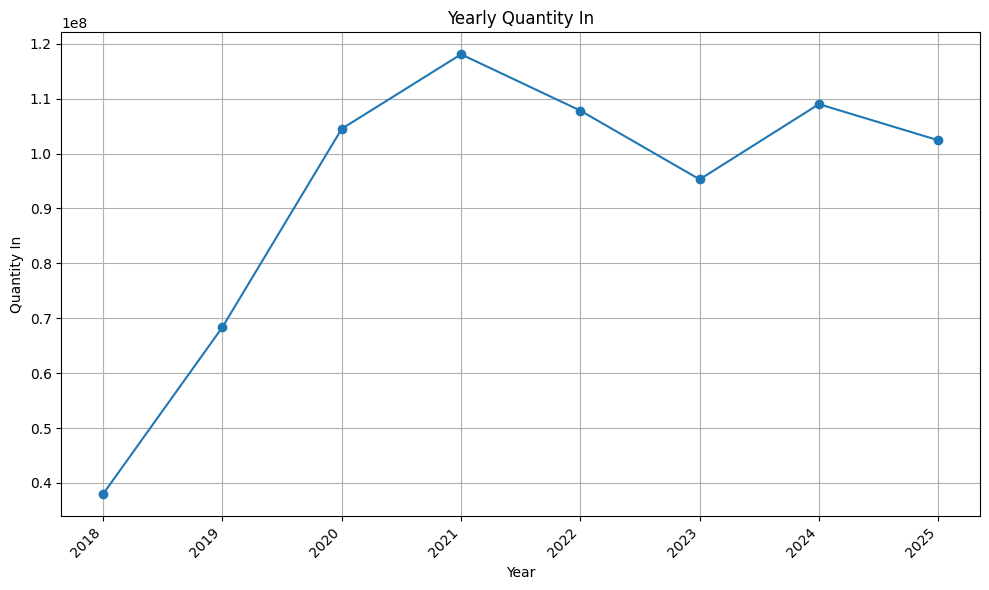

In [27]:
from graph import plot_line_graph

# Ensure datetime
batch_number_in_df["created_time"] = pd.to_datetime(batch_number_in_df["created_time"], errors="coerce")

# Aggregate yearly
yearly_df = (
    batch_number_in_df
    .groupby(batch_number_in_df["created_time"].dt.year)["quantity_in"]
    .sum()
    .reset_index()
    .rename(columns={"created_time": "year"})
)

# Plot
plot_line_graph(
    yearly_df["year"],
    yearly_df["quantity_in"],
    title="Yearly Quantity In",
    x_label="Year",
    y_label="Quantity In"
)


In [ ]:
product_sum = batch_number_in_df.groupby('product_id')['balance_quantity'].sum().sort_values(ascending=False).sort_values(ascending=False)
product_sum

product_id
1410873000007392444    1207590.0
1410873000082039686     934480.0
1410873000066607954     631080.0
1410873000066607071     576270.0
1410873000066607813     568616.0
                         ...    
1410873000043833596          0.0
1410873000044437550          0.0
1410873000044626120          0.0
1410873000044931755          0.0
1410873000137860910          0.0
Name: balance_quantity, Length: 1936, dtype: float64

In [55]:
import pandas as pd

# Ensure datetime
batch_number_in_df["created_time"] = pd.to_datetime(batch_number_in_df["created_time"], errors="coerce")

# Group by product + week
weekly_sum = (
    batch_number_in_df
    .groupby([
        "product_id",
        batch_number_in_df["created_time"].dt.to_period("W")
    ])["quantity_in"]
    .sum()
    .reset_index()
    .rename(columns={"created_time": "week"})
)

# Optional: sort by quantity
weekly_sum = weekly_sum.sort_values(by="week", ascending=False)

print(weekly_sum.head())


                product_id                   week  quantity_in
23679  1410873000137860910  2025-09-22/2025-09-28      25000.0
6471   1410873000000898485  2025-09-22/2025-09-28      30720.0
22808  1410873000082039686  2025-09-22/2025-09-28      36000.0
14866  1410873000028120784  2025-09-22/2025-09-28      15000.0
19065  1410873000047475772  2025-09-22/2025-09-28      19375.0


/var/folders/m7/x79pvj7n0mxdf4v8ky2kds6h0000gn/T/ipykernel_62896/2316734183.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  batch_number_in_df["created_time"].dt.to_period("W")


In [56]:
weekly_sum

,product_id,week,quantity_in
23679,1410873000137860910,2025-09-22/2025-09-28,25000.0
6471,1410873000000898485,2025-09-22/2025-09-28,30720.0
22808,1410873000082039686,2025-09-22/2025-09-28,36000.0
14866,1410873000028120784,2025-09-22/2025-09-28,15000.0
19065,1410873000047475772,2025-09-22/2025-09-28,19375.0
...,...,...,...
2329,1410873000000138253,2018-07-30/2018-08-05,77256.0
2392,1410873000000138298,2018-07-30/2018-08-05,100800.0
2395,1410873000000138334,2018-07-30/2018-08-05,36000.0
2400,1410873000000138370,2018-07-30/2018-08-05,21600.0
